
Actual vs Predicted Job Level
   Actual Job Level  Predicted Job Level
0                 2                    1
1                 1                    1
2                 2                    1
3                 1                    1
4                 5                    5
5                 6                    6
6                 6                    5
7                 1                    1
8                 5                    4
9                 2                    1

Accuracy: 0.7


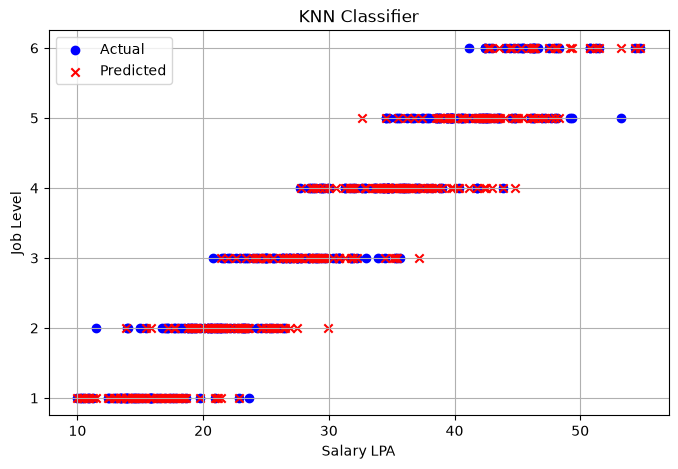

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('preprocessed_data.csv')

X = df[
    [
        "Age",
        "Experience_Years",
        "Performance_Score",
        "Weekly_Working_Hours",
        "Salary_LPA"
    ]
]

y = df["Job_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
result = pd.DataFrame({
    "Actual Job Level": y_test.values,
    "Predicted Job Level": y_pred
})

print("\nActual vs Predicted Job Level")
print(result.head(10))
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

plt.figure(figsize=(8, 5))

plt.scatter(
    df.loc[y_test.index, "Salary_LPA"],
    y_test,
    color="blue",
    label="Actual"
)

plt.scatter(
    df.loc[y_test.index, "Salary_LPA"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted"
)

plt.title("KNN Classifier")
plt.xlabel("Salary LPA")
plt.ylabel("Job Level")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
df.columns

Index(['Employee_Id', 'Age', 'Experience_Years', 'Education_Level',
       'Job_Level', 'Department', 'Performance_Score', 'Weekly_Working_Hours',
       'Salary_LPA'],
      dtype='str')